In [ ]:
while True:
  pass

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from datetime import datetime

def date_parser(date_str):
  """Parses date string assuming day is listed first (dd/mm/yyyy)."""
  return datetime.strptime(date_str, '%d/%m/%Y').date()  # Assumes your date format

existing_df = pd.read_excel(
    '/content/drive/MyDrive/EXISTING_CUSTOMERS_NEW.xlsx',
    parse_dates=['DATE_OF_PURCHASE'],
    converters={'DATE_OF_PURCHASE': date_parser}
)
existing_df = existing_df[existing_df['GROSS_SALES_EXTENDED_SUM'] != 0]
existing_df

,ENTRY_NO,CUST_NBR,CUST_NM,PYRAMID_SEGMENT_DESC,MENU_GROUPING,PIM_CLASS_DESC,QUANTITY_SHIPPED_SUM,NET_WEIGHT_SHIPPED_SUM,GROSS_SALES_EXTENDED_SUM,TOTAL_ALLOWANCE_SUM,CITY,SUB_SEGMENT,DATE_OF_PURCHASE
0,0,31086564,BELLINI'S LATHAM,INDEPENDENT RESTAURATEURS,"PIZZA, PASTA & ITALIAN","PRODUCE, FRESH",2379.8334,45594.90,69660.66,8108.003322,LATHAM,"PIZZA, PASTA & ITALIAN",2019-01-01
1,1,61071932,SAGAMORE RESORT,HOSPITALITY,HOSPITALITY (PYR),PROCESSED MEAT,734.0000,8493.67,35917.86,1796.960077,BOLTON LANDING,LODGING,2019-01-01
2,2,31560238,MAX 410,INDEPENDENT RESTAURATEURS,"STEAK, SEAFOOD & FISH",OILS & SHORTENING,124.1667,2361.03,8391.95,553.197529,GLENVILLE,"STEAK, SEAFOOD & FISH",2019-01-01
3,3,51327310,FORNO BISTRO,INDEPENDENT RESTAURATEURS,EUROPEAN,"PRODUCE, FRESH",1694.3333,18219.45,41303.43,5176.114124,SARATOGA SPRINGS,EUROPEAN,2019-01-01
4,4,71320253,MERCANTILE KITCHEN & BAR,INDEPENDENT RESTAURATEURS,"BAR & GRILL, BREW PUB, & EATERTAINMENT",DISPOSABLES,657.1667,7998.27,31347.94,10150.959710,SARATOGA SPRINGS,"BAR & GRILL, BREW PUB, & EATERTAINMENT",2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18434,18434,1171271,HAMLET & GHOST,INDEPENDENT RESTAURATEURS,"BAR & GRILL, BREW PUB, & EATERTAINMENT","APPETIZERS, ENTREES, & POTATOES REF & FZN",1.0000,3.40,51.92,12.971301,SARATOGA SPRINGS,"BAR & GRILL, BREW PUB, & EATERTAINMENT",2023-12-01
18435,18435,81071466,LAKESIDE CIDER MLL FARM Q,INDEPENDENT RESTAURATEURS,CLASSIC & VARIED MENU,"BEEF, GROUND OR PROCESSED",2.0000,20.00,78.90,9.670606,BALLSTON LAKE,CLASSIC & VARIED MENU,2023-12-01
18436,18436,1113323,6 HOUSE PUB,INDEPENDENT RESTAURATEURS,CLASSIC & VARIED MENU,MEAT SUBSTITUTE,2.0000,21.00,149.15,6.760963,WILLIAMSTOWN,CLASSIC & VARIED MENU,2023-12-01
18437,18437,91477364,BOWLED DELMAR,INDEPENDENT RESTAURATEURS,"SANDWICHES, SOUPS AND SALADS, DELI, SUBS & HOT...",BEVERAGE,1.0000,6.67,64.66,3.270000,DELMAR,"SANDWICHES, SOUPS AND SALADS, DELI, SUBS & HOT...",2023-12-01


Enter Customer Number: 61093
Data for Customer 61093:
       DATE_OF_PURCHASE  GROSS_SALES_EXTENDED_SUM
1795        2019-06-01                   9653.28
2059        2019-07-01                 101551.97
3384        2019-12-01                    872.66
5052        2020-05-01                     66.94
5669        2020-07-01                    289.11
6296        2020-09-01                  85831.85
7713        2021-02-01                    710.25
7788        2021-02-01                   7216.35
8387        2021-04-01                  32801.50
9537        2021-08-01                 146085.29
9604        2021-08-01                   3518.50
9782        2021-08-01                    106.56
10676       2021-11-01                  11742.23
10993       2021-12-01                  59076.50
11064       2022-01-01                   2305.90
11632       2022-02-01                  23778.76
13162       2022-07-01                  10789.35
13513       2022-08-01                   7679.20
14122       20

<ipython-input-59-3cc6502e197e>:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  customer_data = customer_data['GROSS_SALES_EXTENDED_SUM'].resample('M').sum()
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


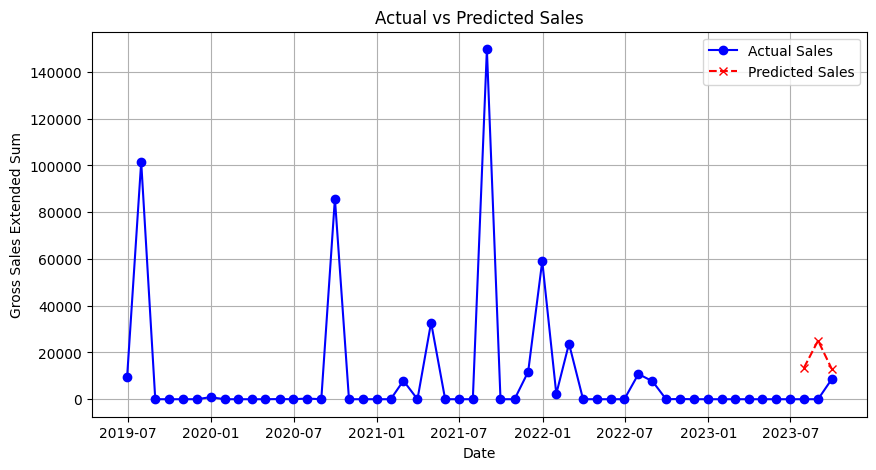

Actual vs Predicted Sales for Customer 61093 :
             Actual Sales  Predicted Sales
2023-07-31          0.00     13484.380496
2023-08-31          0.00     25067.740609
2023-09-30       8534.67     13017.646958


In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Load data
data = existing_df
data = existing_df.copy()

# Convert CUST_NBR to a consistent type (e.g., string) in both the DataFrame and input
data['CUST_NBR'] = data['CUST_NBR'].astype(str)

# Function to preprocess data for a specific customer
def preprocess_customer_data(data, cust_nbr):
    cust_nbr = str(cust_nbr)  # Ensure input is a string to match the DataFrame column type

    # Filter data for the given customer
    customer_data = data[data['CUST_NBR'] == cust_nbr]

    # Check if customer has any records
    if customer_data.empty:
        print(f"No data found for Customer {cust_nbr}. Please check the customer number or data format.")
        return None

    # Display initial data for confirmation
    print(f"Data for Customer {cust_nbr}:\n", customer_data[['DATE_OF_PURCHASE', 'GROSS_SALES_EXTENDED_SUM']], "\n")

    # Sort data by date and set index for resampling
    customer_data = customer_data.sort_values('DATE_OF_PURCHASE')
    customer_data.set_index('DATE_OF_PURCHASE', inplace=True)

    # Aggregate by month and sum GROSS_SALES_EXTENDED_SUM
    customer_data = customer_data['GROSS_SALES_EXTENDED_SUM'].resample('M').sum()

    # Check if there’s only one transaction record
    if len(customer_data) < 4:
        print(f"Insufficient data to model for Customer {cust_nbr}. Need at least 3 purchase records.")
        return None

    return customer_data

# order = (p,d,q) , seasonal_order=(P, D, Q, S)
def sarima_forecast(customer_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)):

    # Split data into train and test sets (last 3 months for testing)
    train_data = customer_data[:-3]
    test_data = customer_data[-3:]

    # Display train and test data for presentation
    print("Training data sample:\n", train_data, "\n")
    print("Testing data sample (actual sales):\n", test_data, "\n")

    # Fit SARIMA model
    model = sm.tsa.statespace.SARIMAX(
        train_data,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = model.fit(disp=False)

    # Forecast the next 3 periods (months)
    forecast = sarima_fit.get_forecast(steps=3)
    predicted_sales = forecast.predicted_mean
    print("Predicted Sales for the next 3 months:\n", predicted_sales, "\n")

    # Combine actual and predicted sales for comparison
    results = pd.DataFrame({
        'Actual Sales': test_data,
        'Predicted Sales': predicted_sales
    })
    # Plot actual vs predicted sales as a line graph
    plt.figure(figsize=(10, 5))
    plt.plot(customer_data.index, customer_data, label='Actual Sales', color='blue', marker='o', linestyle='-')
    plt.plot(predicted_sales.index, predicted_sales, label='Predicted Sales', color='red', marker='x', linestyle='--')
    plt.title(f"Actual vs Predicted Sales")
    plt.xlabel("Date")
    plt.ylabel("Gross Sales Extended Sum")
    plt.legend()
    plt.grid()
    plt.show()
    return results

# Example usage: input a specific customer number and predict
cust_nbr_input = input("Enter Customer Number: ")

# Encode categorical features if needed (e.g., CITY, PYRAMID_SEGMENT_DESC, MENU_GROUPING)
le = LabelEncoder()
data['CITY'] = le.fit_transform(data['CITY'])
data['PYRAMID_SEGMENT_DESC'] = le.fit_transform(data['PYRAMID_SEGMENT_DESC'])
data['MENU_GROUPING'] = le.fit_transform(data['MENU_GROUPING'])

# Preprocess data for the selected customer
customer_sales_data = preprocess_customer_data(data, cust_nbr_input)

# Generate forecast and display results if data is sufficient
if customer_sales_data is not None:
    results = sarima_forecast(customer_sales_data)
    if results is not None:
        print("Actual vs Predicted Sales for Customer", cust_nbr_input, ":\n", results)


Moving Average

In [ ]:
import pandas as pd
import numpy as np

# Load data
data = existing_df.copy()

# Ensure CUST_NBR is treated as a string
data['CUST_NBR'] = data['CUST_NBR'].astype(str)

# Function to preprocess data for each customer and return sales data for forecasting
def preprocess_customer_data(data, cust_nbr):
    customer_data = data[data['CUST_NBR'] == cust_nbr]['GROSS_SALES_EXTENDED_SUM'].reset_index(drop=True)
    if len(customer_data) < 4:
        return None  # Return None if there is insufficient data
    return customer_data

# Function to predict the last sale using Moving Average
def moving_average_forecast(sales_data, window_size=3):
    # Calculate the moving average over the last 'window_size' data points
    if len(sales_data) < window_size:
        # If there are fewer data points than the window size, take the mean of all available points
        return sales_data.mean()
    else:
        return sales_data[-window_size:].mean()  # Moving average of last 'window_size' sales

# Calculate accuracy metrics
def calculate_accuracy_metrics(actual, predicted):
    mae = np.abs(actual - predicted)  # Mean Absolute Error
    mape = np.abs((actual - predicted) / actual) * 100 if actual != 0 else np.nan  # Mean Absolute Percentage Error
    return mae, mape

# Loop through each customer, make predictions, and store results
results = []
unique_customers = data['CUST_NBR'].unique()

for cust_nbr in unique_customers:
    # Get sales data for the customer
    sales_data = preprocess_customer_data(data, cust_nbr)

    if sales_data is not None and len(sales_data) > 1:
        # Predict the last sale using moving average
        forecasted_last_sale = moving_average_forecast(sales_data)
        actual_last_sale = sales_data.iloc[-1]

        # Calculate accuracy metrics
        mae, mape = calculate_accuracy_metrics(actual_last_sale, forecasted_last_sale)

        # Store results
        results.append({
            'CUST_NBR': cust_nbr,
            'Actual_Last_Sale': actual_last_sale,
            'Forecasted_Last_Sale': forecasted_last_sale,
            'MAE': mae,
            'MAPE': mape
        })

# Create DataFrame with results
results_df = pd.DataFrame(results)

# Calculate overall accuracy metrics
overall_mae = results_df['MAE'].mean()
overall_mape = results_df['MAPE'].mean(skipna=True)  # Skip NaN values if any

print("Overall Model Accuracy:")
print(f"Mean Absolute Error (MAE): {overall_mae}")
print(f"Mean Absolute Percentage Error (MAPE): {overall_mape}%")

print("\nIndividual Customer Accuracy Metrics:")
print(results_df)


Overall Model Accuracy:
Mean Absolute Error (MAE): 7895.283913580247
Mean Absolute Percentage Error (MAPE): 918.0715542095826%

Individual Customer Accuracy Metrics:
      CUST_NBR  Actual_Last_Sale  Forecasted_Last_Sale            MAE  \
0     31086564           3715.70          39147.130000   35431.430000   
1     61071932            939.09          40376.353333   39437.263333   
2     31560238          26862.67          20269.490000    6593.180000   
3     51327310          12578.18          30757.363333   18179.183333   
4     71320253          18147.78          25507.560000    7359.780000   
...        ...               ...                   ...            ...   
1075  11371788            306.64           3996.213333    3689.573333   
1076  11482809            186.24           3529.430000    3343.190000   
1077  30923106         116834.86         256832.886667  139998.026667   
1078  41365271          46998.81          18320.370000   28678.440000   
1079   1071828            184.0

exponential smoothing

In [ ]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# Load data
data = existing_df.copy()

# Ensure CUST_NBR is treated as a string
data['CUST_NBR'] = data['CUST_NBR'].astype(str)

# Function to preprocess data for each customer and return sales data for forecasting
def preprocess_customer_data(data, cust_nbr):
    customer_data = data[data['CUST_NBR'] == cust_nbr]['GROSS_SALES_EXTENDED_SUM'].reset_index(drop=True)
    if len(customer_data) < 4:
        return None  # Return None if there is insufficient data
    return customer_data

# Function to predict the last sale using Exponential Smoothing
def exponential_smoothing_forecast(sales_data, smoothing_level=0.3):
    # Fit the Exponential Smoothing model on all but the last sale
    model = ExponentialSmoothing(sales_data[:-1], trend='additive', seasonal=None)
    fit = model.fit(smoothing_level=smoothing_level)

    # Forecast the next value (last sale)
    last_sale_forecast = fit.forecast(steps=1).iloc[0]
    return last_sale_forecast

# Calculate accuracy metrics
def calculate_accuracy_metrics(actual, predicted):
    mae = np.abs(actual - predicted)  # Mean Absolute Error
    mape = np.abs((actual - predicted) / actual) * 100 if actual != 0 else np.nan  # Mean Absolute Percentage Error
    return mae, mape

# Loop through each customer, make predictions, and store results
results = []
unique_customers = data['CUST_NBR'].unique()

for cust_nbr in unique_customers:
    # Get sales data for the customer
    sales_data = preprocess_customer_data(data, cust_nbr)

    if sales_data is not None and len(sales_data) > 1:
        # Predict the last sale
        forecasted_last_sale = exponential_smoothing_forecast(sales_data)
        actual_last_sale = sales_data.iloc[-1]

        # Calculate accuracy metrics
        mae, mape = calculate_accuracy_metrics(actual_last_sale, forecasted_last_sale)

        # Store results
        results.append({
            'CUST_NBR': cust_nbr,
            'Actual_Last_Sale': actual_last_sale,
            'Forecasted_Last_Sale': forecasted_last_sale,
            'MAE': mae,
            'MAPE': mape
        })

# Create DataFrame with results
results_df = pd.DataFrame(results)

# Calculate overall accuracy metrics
overall_mae = results_df['MAE'].mean()
overall_mape = results_df['MAPE'].mean(skipna=True)  # Skip NaN values if any

print("Overall Model Accuracy:")
print(f"Mean Absolute Error (MAE): {overall_mae}")
print(f"Mean Absolute Percentage Error (MAPE): {overall_mape}%")

print("\nIndividual Customer Accuracy Metrics:")
print(results_df)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_

Overall Model Accuracy:
Mean Absolute Error (MAE): 13080.53501406988
Mean Absolute Percentage Error (MAPE): 2308.9311869121934%

Individual Customer Accuracy Metrics:
      CUST_NBR  Actual_Last_Sale  Forecasted_Last_Sale           MAE  \
0     31086564           3715.70          5.655589e+04  5.284019e+04   
1     61071932            939.09          1.047666e+04  9.537566e+03   
2     31560238          26862.67          1.479038e+04  1.207229e+04   
3     51327310          12578.18          3.982253e+04  2.724435e+04   
4     71320253          18147.78          2.585619e+04  7.708408e+03   
...        ...               ...                   ...           ...   
1075  11371788            306.64          4.791756e+03  4.485116e+03   
1076  11482809            186.24          8.722120e+03  8.535880e+03   
1077  30923106         116834.86          1.146033e+06  1.029199e+06   
1078  41365271          46998.81          2.495219e+03  4.450359e+04   
1079   1071828            184.05         

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Sarima


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load data
data = existing_df.copy()

# Ensure CUST_NBR is treated as a string
data['CUST_NBR'] = data['CUST_NBR'].astype(str)

# Function to preprocess data for each customer and return sales data for forecasting
def preprocess_customer_data(data, cust_nbr):
    customer_data = data[data['CUST_NBR'] == cust_nbr]['GROSS_SALES_EXTENDED_SUM'].reset_index(drop=True)
    if len(customer_data) < 4:
        return None  # Return None if there is insufficient data
    return customer_data

# Function to predict the last sale using SARIMA
def sarima_forecast(sales_data, seasonal_period=6):
    # Fit the SARIMA model (order=(p,d,q) with seasonal order (P,D,Q,s))
    # We will try an ARIMA order of (1,1,1) and seasonal order of (1,1,1,6) for example.
    try:
        model = sm.tsa.SARIMAX(sales_data,
                               order=(1, 1, 1),
                               seasonal_order=(1, 1, 1, seasonal_period))
        fit = model.fit(disp=False)

        # Forecast the next value (last sale)
        last_sale_forecast = fit.forecast(steps=1).iloc[0]
        return last_sale_forecast
    except Exception as e:
        print(f"Error fitting SARIMA model for customer: {e}")
        return np.nan  # Return NaN if SARIMA model fitting fails

# Calculate accuracy metrics
def calculate_accuracy_metrics(actual, predicted):
    mae = np.abs(actual - predicted)  # Mean Absolute Error
    mape = np.abs((actual - predicted) / actual) * 100 if actual != 0 else np.nan  # Mean Absolute Percentage Error
    return mae, mape

# Loop through each customer, make predictions, and store results
results = []
unique_customers = data['CUST_NBR'].unique()

for cust_nbr in unique_customers:
    # Get sales data for the customer
    sales_data = preprocess_customer_data(data, cust_nbr)

    if sales_data is not None and len(sales_data) > 1:
        # Predict the last sale using SARIMA
        forecasted_last_sale = sarima_forecast(sales_data)
        actual_last_sale = sales_data.iloc[-1]

        # Calculate accuracy metrics
        mae, mape = calculate_accuracy_metrics(actual_last_sale, forecasted_last_sale)

        # Store results
        results.append({
            'CUST_NBR': cust_nbr,
            'Actual_Last_Sale': actual_last_sale,
            'Forecasted_Last_Sale': forecasted_last_sale,
            'MAE': mae,
            'MAPE': mape
        })

# Create DataFrame with results
results_df = pd.DataFrame(results)

# Calculate overall accuracy metrics
overall_mae = results_df['MAE'].mean()
overall_mape = results_df['MAPE'].mean(skipna=True)  # Skip NaN values if any

print("Overall Model Accuracy:")
print(f"Mean Absolute Error (MAE): {overall_mae}")
print(f"Mean Absolute Percentage Error (MAPE): {overall_mape}%")

print("\nIndividual Customer Accuracy Metrics:")
print(results_df)


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  wa

Error fitting SARIMA model for customer: LU decomposition error.


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  wa

Error fitting SARIMA model for customer: LU decomposition error.


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters exce

...

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/loc

Error fitting SARIMA model for customer: too many indices for array: array is 0-dimensional, but 1 were indexed


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estima

Overall Model Accuracy:
Mean Absolute Error (MAE): 19186.162843125476
Mean Absolute Percentage Error (MAPE): 3729.1190581957194%

Individual Customer Accuracy Metrics:
      CUST_NBR  Actual_Last_Sale  Forecasted_Last_Sale           MAE  \
0     31086564           3715.70          66064.422381  6.234872e+04   
1     61071932            939.09          23544.077665  2.260499e+04   
2     31560238          26862.67          30610.516412  3.747846e+03   
3     51327310          12578.18          21672.774283  9.094594e+03   
4     71320253          18147.78          43048.637647  2.490086e+04   
...        ...               ...                   ...           ...   
1075  11371788            306.64           1685.296940  1.378657e+03   
1076  11482809            186.24           6916.781464  6.730541e+03   
1077  30923106         116834.86         116834.860000  1.455192e-11   
1078  41365271          46998.81          99104.363762  5.210555e+04   
1079   1071828            184.05        

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Arima


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Load data
data = existing_df.copy()

# Ensure CUST_NBR is treated as a string
data['CUST_NBR'] = data['CUST_NBR'].astype(str)

# Function to check if the data is stationary
def check_stationarity(sales_data):
    result = adfuller(sales_data)
    return result[1] <= 0.05  # p-value < 0.05 means the data is stationary

# Function to preprocess data for each customer and return sales data for forecasting
def preprocess_customer_data(data, cust_nbr):
    customer_data = data[data['CUST_NBR'] == cust_nbr]['GROSS_SALES_EXTENDED_SUM'].reset_index(drop=True)
    if len(customer_data) < 4:
        return None  # Return None if there is insufficient data
    return customer_data

# Function to make sales data stationary by differencing
def difference_data(sales_data):
    return sales_data.diff().dropna()

# Function to predict the last sale using ARIMA
def arima_forecast(sales_data):
    # Check if the data is stationary
    if not check_stationarity(sales_data):
        # Difference the data to make it stationary
        sales_data = difference_data(sales_data)

    # Create a simple RangeIndex for the time series data (this avoids datetime-related warnings)
    sales_data.index = pd.RangeIndex(start=0, stop=len(sales_data), step=1)

    # Fit the ARIMA model (order=(p,d,q))
    model = sm.tsa.ARIMA(sales_data, order=(1, 1, 1))  # ARIMA(1,1,1)
    fit = model.fit()  # Fit the model (removed disp argument)

    # Forecast the next value (last sale)
    last_sale_forecast = fit.forecast(steps=1).iloc[0]
    return last_sale_forecast

# Loop through each customer, make predictions, and store results
results = []
unique_customers = data['CUST_NBR'].unique()

for cust_nbr in unique_customers:
    # Get sales data for the customer
    sales_data = preprocess_customer_data(data, cust_nbr)

    if sales_data is not None and len(sales_data) > 1:
        # Predict the last sale using ARIMA
        forecasted_last_sale = arima_forecast(sales_data)
        actual_last_sale = sales_data.iloc[-1]

        # Store results
        results.append({
            'CUST_NBR': cust_nbr,
            'Actual_Last_Sale': actual_last_sale,
            'Forecasted_Last_Sale': forecasted_last_sale
        })

# Create DataFrame with results
results_df = pd.DataFrame(results)

# Calculate overall accuracy metrics
overall_mae = np.mean(np.abs(results_df['Actual_Last_Sale'] - results_df['Forecasted_Last_Sale']))
overall_mape = np.mean(np.abs((results_df['Actual_Last_Sale'] - results_df['Forecasted_Last_Sale']) / results_df['Actual_Last_Sale'])) * 100

print("Overall Model Accuracy:")
print(f"Mean Absolute Error (MAE): {overall_mae}")
print(f"Mean Absolute Percentage Error (MAPE): {overall_mape}%")

print("\nIndividual Customer Accuracy Metrics:")
print(results_df)


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/sta

LinAlgError: LU decomposition error.

In [ ]:
import pandas as pd
import numpy as np

# Load data
data = existing_df.copy()

# Ensure CUST_NBR is treated as a string
data['CUST_NBR'] = data['CUST_NBR'].astype(str)

# Function to preprocess data for a specific customer
def preprocess_customer_data(data, cust_nbr):
    cust_nbr = str(cust_nbr)
    customer_data = data[data['CUST_NBR'] == cust_nbr]

    if customer_data.empty:
        print(f"No data found for Customer {cust_nbr}. Please check the customer number or data format.")
        return None

    print(f"Data for Customer {cust_nbr}:\n", customer_data[['GROSS_SALES_EXTENDED_SUM']], "\n")

    if len(customer_data) < 4:
        print(f"Insufficient data to model for Customer {cust_nbr}. Need at least 3 purchase records.")
        return None

    return customer_data['GROSS_SALES_EXTENDED_SUM'].reset_index(drop=True)

# Function to predict next sale using Moving Average
def moving_average_forecast(sales_data, window=3):
    # Calculate moving average for the last 'window' periods (data points)
    if len(sales_data) < window:
        print(f"Insufficient data for moving average. Need at least {window} data points.")
        return None

    forecast = sales_data[-window:].mean()  # Use the average of the last 'window' periods
    return forecast

# Example usage: input a specific customer number and predict
cust_nbr_input = input("Enter Customer Number: ")
customer_sales_data = preprocess_customer_data(data, cust_nbr_input)

# Generate forecast if data is sufficient
if customer_sales_data is not None:
    moving_avg_forecast = moving_average_forecast(customer_sales_data)
    print(f"Moving Average Predicted Next Sale for Customer {cust_nbr_input}: {moving_avg_forecast}")


Enter Customer Number: 61093
Data for Customer 61093:
        GROSS_SALES_EXTENDED_SUM
1795                    9653.28
2059                  101551.97
3384                     872.66
5052                      66.94
5669                     289.11
6296                   85831.85
7713                     710.25
7788                    7216.35
8387                   32801.50
9537                  146085.29
9604                    3518.50
9782                     106.56
10676                  11742.23
10993                  59076.50
11064                   2305.90
11632                  23778.76
13162                  10789.35
13513                   7679.20
14122                     93.30
17217                   8534.67 

Moving Average Predicted Next Sale for Customer 61093: 5435.723333333333
